# Iteration 4 — combos in the training set

Same `BaselineCNN`, same crop pipeline (`augment=True`). Two changes vs iteration 2/3:

1. `labels.csv` now has **525 combo images in the train split** (generated by
   `generate_combos.py --n-train 525`, train scenes only). The model now sees
   defects stacked during training, which iterations 2/3 showed it couldn't
   calibrate for on its own.
2. **15 epochs** instead of 10 (every prior run was still improving at epoch 10).

Then per-class threshold tuning on validation, as in iteration 3.

Target to beat (crop, tuned): **val macro-F1 0.876 (all) / 0.684 (combo)**, and
especially **combo noise F1 ~0.36**.
Test split is not touched.

In [1]:
import os
from pathlib import Path

if Path.cwd().name == "notebooks":
    os.chdir("..")
print("working dir:", Path.cwd())

import sys
sys.path.append("src")

import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import matplotlib.pyplot as plt

from dataset import build_dataloaders
from model import BaselineCNN
from metrics import (evaluate_model, compute_metrics, print_metrics,
                     tune_thresholds, combo_mask, DEFECT_COLUMNS)

torch.manual_seed(42)
np.random.seed(42)

device = "cuda" if torch.cuda.is_available() else "cpu"
print("device:", device)

working dir: c:\Users\Shamik\Desktop\ImageQuality_Classifier\ImageQuality_Classifier
device: cuda


## 1. Data — crop pipeline, train split now includes 525 combos

In [2]:
loaders = build_dataloaders(batch_size=32, augment=True)
for name, ldr in loaders.items():
    df = ldr.dataset.df
    n_combo = int(df["filename"].str.contains("_combo_").sum())
    print(f"{name:5s} {len(df):5d} images ({n_combo} combos) | {len(ldr):3d} batches")

train  3675 images (525 combos) | 115 batches
val     722 images (50 combos) |  23 batches
test    728 images (50 combos) |  23 batches


## 2. Model, loss, optimizer (unchanged)

In [3]:
model = BaselineCNN().to(device)
criterion = nn.BCEWithLogitsLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
print(f"{sum(p.numel() for p in model.parameters()):,} parameters")

8,777,797 parameters


## 3. Training helper (unchanged)

In [4]:
def train_one_epoch(model, loader, criterion, optimizer, device):
    model.train()
    running_loss, n_batches = 0.0, 0
    for images, labels in loader:
        images = images.to(device)
        labels = labels.to(device)
        optimizer.zero_grad()
        loss = criterion(model(images), labels)
        loss.backward()
        optimizer.step()
        running_loss += loss.item()
        n_batches += 1
    return running_loss / n_batches

## 4. Epoch loop (15 epochs)

In [5]:
NUM_EPOCHS = 15
CKPT_PATH = Path("models/traincombo_best.pt")
CKPT_PATH.parent.mkdir(exist_ok=True)

history = []
best_val_f1 = -1.0

for epoch in range(1, NUM_EPOCHS + 1):
    train_loss = train_one_epoch(model, loaders["train"], criterion, optimizer, device)

    y_true, y_prob, val_loss = evaluate_model(model, loaders["val"], device, criterion)
    vm = compute_metrics(y_true, y_prob)
    val_f1 = vm["macro_f1"]

    row = {"epoch": epoch, "train_loss": train_loss, "val_loss": val_loss, "val_macro_f1": val_f1}
    for c in DEFECT_COLUMNS:
        row[f"f1_{c}"] = vm["per_class"][c]["f1"]
    history.append(row)

    flag = ""
    if val_f1 > best_val_f1:
        best_val_f1 = val_f1
        torch.save(model.state_dict(), CKPT_PATH)
        flag = "  <- saved (best so far)"

    print(f"epoch {epoch:2d} | train_loss {train_loss:.4f} | val_loss {val_loss:.4f} "
          f"| val_macro_f1 {val_f1:.3f}{flag}")

print(f"\nbest val macro-F1: {best_val_f1:.3f}  ->  {CKPT_PATH}")

epoch  1 | train_loss 0.3812 | val_loss 0.2822 | val_macro_f1 0.639  <- saved (best so far)
epoch  2 | train_loss 0.2759 | val_loss 0.2605 | val_macro_f1 0.712  <- saved (best so far)
epoch  3 | train_loss 0.2462 | val_loss 0.2226 | val_macro_f1 0.744  <- saved (best so far)
epoch  4 | train_loss 0.2091 | val_loss 0.2045 | val_macro_f1 0.806  <- saved (best so far)
epoch  5 | train_loss 0.1845 | val_loss 0.1603 | val_macro_f1 0.860  <- saved (best so far)
epoch  6 | train_loss 0.1666 | val_loss 0.1413 | val_macro_f1 0.870  <- saved (best so far)
epoch  7 | train_loss 0.1437 | val_loss 0.1654 | val_macro_f1 0.834
epoch  8 | train_loss 0.1435 | val_loss 0.1434 | val_macro_f1 0.864
epoch  9 | train_loss 0.1401 | val_loss 0.1284 | val_macro_f1 0.891  <- saved (best so far)
epoch 10 | train_loss 0.1294 | val_loss 0.1161 | val_macro_f1 0.899  <- saved (best so far)
epoch 11 | train_loss 0.1078 | val_loss 0.1425 | val_macro_f1 0.867
epoch 12 | train_loss 0.1047 | val_loss 0.1495 | val_macro_f

In [6]:
hist = pd.DataFrame(history)
hist.to_csv("models/traincombo_history.csv", index=False)
hist

,epoch,train_loss,val_loss,val_macro_f1,f1_blur,f1_underexposed,f1_overexposed,f1_noise,f1_contrast
0,1,0.381182,0.282184,0.639034,0.563291,0.875421,0.819383,0.163743,0.773333
1,2,0.275928,0.260513,0.711994,0.709163,0.904762,0.758410,0.370732,0.816901
2,3,0.246189,0.222647,0.744204,0.765957,0.882155,0.884615,0.598291,0.590000
3,4,0.209081,0.204511,0.806146,0.811024,0.949275,0.736842,0.688000,0.845588
4,5,0.184490,0.160283,0.860431,0.831615,0.932806,0.875912,0.827338,0.834483
5,6,0.166605,0.141328,0.869922,0.866667,0.970370,0.870849,0.800000,0.841727
6,7,0.143673,0.165356,0.834037,0.786325,0.909091,0.883534,0.766234,0.825000
7,8,0.143501,0.143382,0.864143,0.790274,0.977444,0.875912,0.830645,0.846442
8,9,0.140125,0.128422,0.890827,0.831276,0.962121,0.896825,0.886364,0.877551
9,10,0.129382,0.116105,0.898885,0.880309,0.949640,0.910506,0.871212,0.882759


## 5. Diagnostics

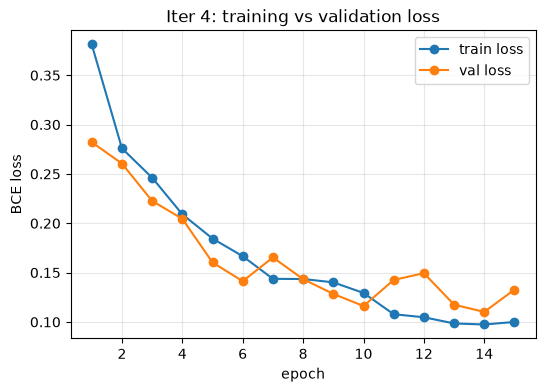

In [7]:
plt.figure(figsize=(6, 4))
plt.plot(hist["epoch"], hist["train_loss"], marker="o", label="train loss")
plt.plot(hist["epoch"], hist["val_loss"], marker="o", label="val loss")
plt.xlabel("epoch"); plt.ylabel("BCE loss"); plt.title("Iter 4: training vs validation loss")
plt.legend(); plt.grid(alpha=0.3); plt.show()

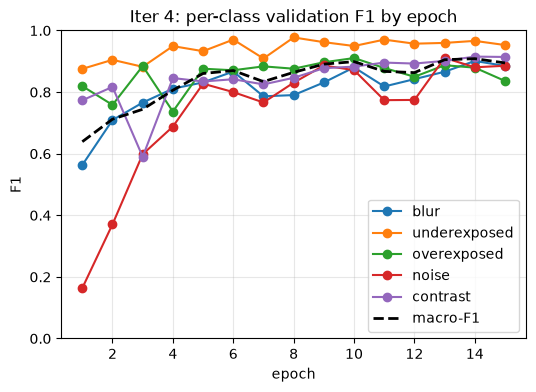

In [8]:
plt.figure(figsize=(6, 4))
for c in DEFECT_COLUMNS:
    plt.plot(hist["epoch"], hist[f"f1_{c}"], marker="o", label=c)
plt.plot(hist["epoch"], hist["val_macro_f1"], "k--", linewidth=2, label="macro-F1")
plt.xlabel("epoch"); plt.ylabel("F1"); plt.title("Iter 4: per-class validation F1 by epoch")
plt.legend(); plt.grid(alpha=0.3); plt.ylim(0, 1); plt.show()

## 6. Evaluate best checkpoint — 0.5 vs tuned, all vs combo

In [9]:
best_model = BaselineCNN().to(device)
best_model.load_state_dict(torch.load(CKPT_PATH, weights_only=True))

y_true, y_prob, _ = evaluate_model(best_model, loaders["val"], device)
cmask = combo_mask(loaders["val"].dataset.df["filename"].values)

thr = tune_thresholds(y_true, y_prob)
print("tuned thresholds:", dict(zip(DEFECT_COLUMNS, thr.round(2))))

print_metrics(compute_metrics(y_true, y_prob),                       "ITER4 VAL all   | 0.5")
print_metrics(compute_metrics(y_true, y_prob, threshold=thr),        "ITER4 VAL all   | tuned")
print_metrics(compute_metrics(y_true[cmask], y_prob[cmask]),         "ITER4 VAL combo | 0.5")
print_metrics(compute_metrics(y_true[cmask], y_prob[cmask], threshold=thr), "ITER4 VAL combo | tuned")

C:\Users\Shamik\AppData\Local\Temp\ipykernel_22240\4270822665.py:2: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  best_model.load_state_dict(torch.load(CKPT_PATH))


tuned thresholds: {'blur': np.float64(0.5), 'underexposed': np.float64(0.5), 'overexposed': np.float64(0.5), 'noise': np.float64(0.75), 'contrast': np.float64(0.65)}

=== ITER4 VAL all   | 0.5 ===
macro-F1 0.909 | macro-P 0.894 | macro-R 0.925 | subset-acc 0.842
class            prec  recall     f1  pr_auc    tp    fp    fn    tn
blur            0.918   0.885  0.901   0.967   123    11    16   572
underexposed    0.956   0.977  0.966   0.995   129     6     3   584
overexposed     0.890   0.869  0.879   0.943   113    14    17   578
noise           0.838   0.928  0.881   0.946   129    25    10   558
contrast        0.871   0.964  0.915   0.951   135    20     5   562

=== ITER4 VAL all   | tuned ===
macro-F1 0.917 | macro-P 0.918 | macro-R 0.918 | subset-acc 0.856
class            prec  recall     f1  pr_auc    tp    fp    fn    tn
blur            0.918   0.885  0.901   0.967   123    11    16   572
underexposed    0.956   0.977  0.966   0.995   129     6     3   584
overexposed     0

## 7. Comparison table

Prior best (iteration 3, crop + tuned): macro-F1 **0.876** all / **0.684** combo,
combo noise F1 **~0.36**.

In [10]:
m_all_t   = compute_metrics(y_true, y_prob, threshold=thr)
m_combo_t = compute_metrics(y_true[cmask], y_prob[cmask], threshold=thr)

pd.DataFrame([
    {"metric": "macro-F1 all (tuned)",     "iter3_crop": 0.876, "iter4_traincombo": round(m_all_t["macro_f1"], 3)},
    {"metric": "macro-F1 combo (tuned)",   "iter3_crop": 0.684, "iter4_traincombo": round(m_combo_t["macro_f1"], 3)},
    {"metric": "noise F1 all (tuned)",     "iter3_crop": 0.746, "iter4_traincombo": round(m_all_t["per_class"]["noise"]["f1"], 3)},
    {"metric": "noise F1 combo (tuned)",   "iter3_crop": 0.364, "iter4_traincombo": round(m_combo_t["per_class"]["noise"]["f1"], 3)},
]).set_index("metric")

,iter3_crop,iter4_traincombo
metric,,
macro-F1 all (tuned),0.876,0.917
macro-F1 combo (tuned),0.684,0.896
noise F1 all (tuned),0.746,0.912
noise F1 combo (tuned),0.364,0.826


## 8. FINAL: test set — run once, at the very end

Freeze the checkpoint AND the tuned thresholds first. Not now.

In [ ]:
# FINAL numbers. Frozen config: models/traincombo_best.pt + threshold 0.5 for every class.
# (Tuned thresholds shown underneath for reference only - they are NOT the frozen choice.)
y_true, y_prob, _ = evaluate_model(best_model, loaders["test"], device)
cmask = combo_mask(loaders["test"].dataset.df["filename"].values)

print_metrics(compute_metrics(y_true, y_prob),                       "ITER4 TEST all   | threshold 0.5  (FINAL)")
print_metrics(compute_metrics(y_true[cmask], y_prob[cmask]),         "ITER4 TEST combo | threshold 0.5  (FINAL)")

print("\n--- for reference only, tuned thresholds ---")
print_metrics(compute_metrics(y_true, y_prob, threshold=thr),               "ITER4 TEST all   | tuned (reference)")
print_metrics(compute_metrics(y_true[cmask], y_prob[cmask], threshold=thr), "ITER4 TEST combo | tuned (reference)")